# Comparing to what we thought we knew about these colony sizes 

Ok for this code, I want to compare our male huddle breeding estimate to what we previously thought the size of the colony was "avg_size" data
from the original dfRFD file (dfRFD_with_predictions_cleaned_final) and the bp estimate from dfHuddle export file 

I have refined how I claculated avg_size - rather than using the colsz data that Michelle gave me, which I found some mistakes in, I have gone back to the publications and am recalculating the means based on the whole timeseries and SD. 

Datasets I used were: 
- Foster-Dyer et al. 2026 (7 colonies 00-24)
- Fretwell et al. 2025 (16 colonies 09-23)
- LaRue et al. 2024 (50 colonies 09-18)
- Wienecke et al. 2024 (ground counts of adults and chicks)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D
from scipy import stats
from scipy.optimize import minimize
from sklearn.utils import resample

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10
})

print('Imports successful')

Imports successful


In [ ]:
INPUTPATH = "/mnt/c/Users/rfo37/OneDrive - University of Canterbury/PostDoc/Population modelling/"

dfRFD = pd.read_excel(os.path.join(INPUTPATH, "dfRFD_with_predictions_cleaned_final.xlsx")) #this one already contains the combined sabrina records - so no need to fix that here.

#dfHuddle = pd.read_excel(os.path.join(INPUTPATH, "dfHuddle_export_final.xlsx"))
dfHuddle = pd.read_excel(os.path.join(INPUTPATH, "Final results/dfHuddle_export_combined_uncertainty.xlsx")) 


# Accurately estimated mean size of colonies based on previous work 

## I want to take the mean and sd for the Fretwell 2025 and LaRue 2024 papers 

Take the mean for as many years that have data - 

Also combined with the estimates from other papers which report new colonies and estimated sizes (Fretwell 2026 preprint, Fretwell 2024)

In [ ]:
import pandas as pd
import numpy as np
import os

# ── Load data files ────────────────────────────────────────────────────────
df_fretwell = pd.read_excel(
    os.path.join(INPUTPATH, "Fretwell_etal2025_WS09-23.xlsx")
)
df_larue = pd.read_csv(
    os.path.join(INPUTPATH, "LaRue_etal2024_colony_results09-18.csv")
)

# ── Load Foster-Dyer et al. 2026 ───────────────────────────────────────────
df_fosterdyer = pd.read_csv(
    os.path.join(INPUTPATH, "Foster-Dyer_etal2026_RS_00-2024.csv")
)


FRETWELL et al. 2025
Shape: (240, 22)

Columns: ['year', 'site_number', 'N_mean', 'N_se', 'N_q025', 'N_q05', 'N_median', 'N_q95', 'N_q975', 'change_since_2009_mean', 'change_since_2009_q025', 'change_since_2009_q05', 'change_since_2009_median', 'change_since_2009_q95', 'change_since_2009_q975', 'prob_decline_since_2009', 'site_id', 'site_name', 'lat', 'lon', 'ice_reg', 'p_ice_reg']

First few rows:
   year  site_number       N_mean         N_se       N_q025        N_q05  \
0  2009            1  7544.471014  2146.217421  4434.771902  4789.695599   
1  2010            1  7100.960985  1919.126169  4277.971425  4595.626139   
2  2011            1  6423.060777  1676.029934  3917.181513  4199.250303   
3  2012            1  5357.356359  1453.950923  3196.443610  3447.860069   
4  2013            1  4470.926074  1282.196031  2563.212969  2777.327858   

      N_median         N_q95        N_q975  change_since_2009_mean  ...  \
0  7200.182815  11515.474740  12687.842250                0.000000

In [ ]:
# ── Simple site inventory and timeseries means ─────────────────────────────

# Fretwell
fretwell_simple = (df_fretwell
    .groupby("site_name")
    .agg(
        n_years    = ("year", "count"),
        year_min   = ("year", "min"),
        year_max   = ("year", "max"),
        N_mean     = ("N_mean", "mean"),
        N_sd       = ("N_mean", "std"),
    )
    .reset_index()
)
fretwell_simple["dataset"] = "Fretwell 2025"
fretwell_simple["period"]  = (fretwell_simple["year_min"].astype(str) +
                               "–" + fretwell_simple["year_max"].astype(str))

# LaRue
larue_simple = (df_larue
    .groupby("site_name")
    .agg(
        n_years    = ("year", "count"),
        year_min   = ("year", "min"),
        year_max   = ("year", "max"),
        N_mean     = ("N_mean", "mean"),
        N_sd       = ("N_mean", "std"),
    )
    .reset_index()
)
larue_simple["dataset"] = "LaRue 2024"
larue_simple["period"]  = (larue_simple["year_min"].astype(str) +
                            "–" + larue_simple["year_max"].astype(str))

# Foster-Dyer
fosterdyer_simple = (df_fosterdyer
    .groupby("site_name")
    .agg(
        n_years    = ("year", "count"),
        year_min   = ("year", "min"),
        year_max   = ("year", "max"),
        N_mean     = ("N_mean", "mean"),
        N_sd       = ("N_mean", "std"),
    )
    .reset_index()
)
fosterdyer_simple["dataset"] = "Foster-Dyer 2026"
fosterdyer_simple["period"]  = (fosterdyer_simple["year_min"].astype(str) +
                                 "–" + fosterdyer_simple["year_max"].astype(str))

# ── Combine all three ──────────────────────────────────────────────────────
df_all = pd.concat([fretwell_simple, larue_simple, fosterdyer_simple],
                    ignore_index=True)


# ──  print long format — easier to read ────────────────────────────────
print(f"\n{'='*75}")
print("LONG FORMAT — mean count per site per dataset")
print(f"{'='*75}")
print(f"{'Site':<25} {'Dataset':<20} {'N_mean':>10} {'N_sd':>10} "
      f"{'n_years':>8} {'Period'}")
print("-" * 80)
for _, r in df_all.sort_values(["site_name", "dataset"]).iterrows():
    print(f"{r['site_name']:<25} {r['dataset']:<20} "
          f"{r['N_mean']:>10,.0f} {r['N_sd']:>10,.0f} "
          f"{int(r['n_years']):>8} {r['period']}")

# ── Export ─────────────────────────────────────────────────────────────────
df_all.to_csv(
    os.path.join(INPUTPATH, "Final results/literature_colony_means_long.csv"),
    index=False,
    float_format="%.0f",
    encoding="utf-8-sig"  # adds BOM so Excel reads UTF-8 correctly
)
print(f"\nExported long format CSV")


LONG FORMAT — mean count per site per dataset
Site                      Dataset                  N_mean       N_sd  n_years Period
--------------------------------------------------------------------------------
Amanda                    LaRue 2024                4,428        655       10 2009–2018
Amundsen                  LaRue 2024                   60         46       10 2009–2018
Astrid                    LaRue 2024                3,217        421       10 2009–2018
Atka                      Fretwell 2025             4,522      1,438       15 2009–2023
Atka                      LaRue 2024                6,960      1,768       10 2009–2018
Auster                    LaRue 2024                4,019        907       10 2009–2018
Barrier                   LaRue 2024                  282        162       10 2009–2018
Bear                      LaRue 2024                3,728      1,469       10 2009–2018
Beaufort                  Foster-Dyer 2026          1,019        403       25 2000–

## Adding in Wienecke most recent counts from 2022

Wienecke et al. 2024

In [ ]:
# ── Wienecke et al. 2024 — manual entry from Table A1 ─────────────────────
df_wienecke = pd.DataFrame([
    {"colony_name": "Kloa",          "date": "2022-09-22", "year": 2022,
     "method": "Ground photography",
     "n_adults": 3470,  "n_chicks": np.nan},
    {"colony_name": "Fold",          "date": "2022-09-20", "year": 2022,
     "method": "Ground photography",
     "n_adults": 361,   "n_chicks": 234},
    {"colony_name": "Darnley",       "date": "2022-11-03", "year": 2022,
     "method": "Aerial photography",
     "n_adults": 1378,  "n_chicks": 7707},
    {"colony_name": "Amanda",        "date": "2022-11-23", "year": 2022,
     "method": "Aerial photography",
     "n_adults": 1424,  "n_chicks": 10485},
    {"colony_name": "West Ice Shelf","date": "2022-11-03", "year": 2022,
     "method": "Aerial photography",
     "n_adults": 2480,  "n_chicks": 7786},
    {"colony_name": "Posadowsky",    "date": "2022-11-03", "year": 2022,
     "method": "Aerial photography",
     "n_adults": 123,   "n_chicks": 155},
    {"colony_name": "Shackleton",    "date": "2022-12-06", "year": 2022,
     "method": "Aerial photography",
     "n_adults": 1339,  "n_chicks": 10738},
    {"colony_name": "Bowman",        "date": "2022-12-06", "year": 2022,
     "method": "Aerial photography",
     "n_adults": 399,   "n_chicks": 2372},
    {"colony_name": "Peterson",      "date": "2022-12-02", "year": 2022,
     "method": "Aerial photography",
     "n_adults": np.nan, "n_chicks": np.nan,
     "notes": "ice broke out in November"},
    {"colony_name": "Sabrina",       "date": "2022-12-02", "year": 2022,
     "method": "Aerial photography",
     "n_adults": 672,   "n_chicks": 4278},
])

df_wienecke["date"]   = pd.to_datetime(df_wienecke["date"])
df_wienecke["source"] = "Wienecke et al. 2024"
df_wienecke["season"] = "spring"

# Total count where available
df_wienecke["n_total"] = df_wienecke["n_adults"].fillna(0) + df_wienecke["n_chicks"].fillna(0)
df_wienecke.loc[df_wienecke["n_adults"].isna() & df_wienecke["n_chicks"].isna(),
                "n_total"] = np.nan

print("Wienecke et al. 2024 — Table A1:")
print(df_wienecke[["colony_name", "date", "method",
                     "n_adults", "n_chicks", "n_total"]].to_string(index=False))
print(f"\nTotal adults (where available): {df_wienecke['n_adults'].sum():,.0f}")
print(f"Total chicks (where available): {df_wienecke['n_chicks'].sum():,.0f}")


Wienecke et al. 2024 — Table A1:
   colony_name       date             method  n_adults  n_chicks  n_total
          Kloa 2022-09-22 Ground photography    3470.0       NaN   3470.0
          Fold 2022-09-20 Ground photography     361.0     234.0    595.0
       Darnley 2022-11-03 Aerial photography    1378.0    7707.0   9085.0
        Amanda 2022-11-23 Aerial photography    1424.0   10485.0  11909.0
West Ice Shelf 2022-11-03 Aerial photography    2480.0    7786.0  10266.0
    Posadowsky 2022-11-03 Aerial photography     123.0     155.0    278.0
    Shackleton 2022-12-06 Aerial photography    1339.0   10738.0  12077.0
        Bowman 2022-12-06 Aerial photography     399.0    2372.0   2771.0
      Peterson 2022-12-02 Aerial photography       NaN       NaN      NaN
       Sabrina 2022-12-02 Aerial photography     672.0    4278.0   4950.0

Total adults (where available): 11,646
Total chicks (where available): 43,755


# Manually edited and added data to create a new datafile called est_size_AllColonies.csv 

This file contains the latest most robust estimate of colony sized based on previous research. 

## Refined avg_size data 

I have improved the methods for calculating the avg_size values, including the SD and the number of years and source that the data is from. 

I have also updated the method for estimating the size of colonies that were not estimated in our work - I want to total these to say our estimate may be added to by this much.

In [10]:
# ── Load new avg_size data ─────────────────────────────────────────────────
df_est_size = pd.read_csv(
    os.path.join(INPUTPATH, "Final data files/est_size_AllColonies.csv")
)

print(f"Shape: {df_est_size.shape}")
print(f"\nColumns: {df_est_size.columns.tolist()}")
print(f"\nFirst few rows:")
print(df_est_size.head(10))
print(f"\nData types:")
print(df_est_size.dtypes)
print(f"\nSite names:")
print(sorted(df_est_size.iloc[:, 0].unique()))

Shape: (71, 9)

Columns: ['site_id', 'colony_x', 'site_name', 'avg_size', 'avg_size-sd', 'source', 'years', 'n_years', 'method']

First few rows:
  site_id         colony_x site_name  avg_size  avg_size-sd  \
0    AMAN       Amanda Bay    Amanda      4428        655.0   
1    AMUN     Amundsen Bay  Amundsen        60         46.0   
2    ASTD           Astrid    Astrid      3217        421.0   
3    ATKA             Atka      Atka      4522       1438.0   
4    AUST           Auster    Auster      4019        907.0   
5    BARR      Barrier Bay   Barrier         0          0.0   
6    BEAN  Beaufort Island  Beaufort      1019        403.0   
7    BEAR   Bear Peninsula      Bear      3728       1469.0   
8    BOWM    Bowman Island    Bowman      1416        652.0   
9    BRYA      Bryan Coast     Bryan      1350        666.0   

                    source      years  n_years method  
0        LaRue et al. 2024  2009–2018       10    VHR  
1        LaRue et al. 2024  2009–2018       10  

In [11]:
# ── Check name overlap ─────────────────────────────────────────────────────
est_sites = set(df_est_size["site_name"].unique())
sar_sites  = set(dfHuddle["colony_name"].unique())

matched   = est_sites & sar_sites
unmatched_est = est_sites - sar_sites
unmatched_sar = sar_sites - est_sites

print(f"Est size sites:  {len(est_sites)}")
print(f"SAR sites:       {len(sar_sites)}")
print(f"Matched:         {len(matched)}")
print(f"\nIn est_size NOT in SAR: {sorted(unmatched_est)}")
print(f"\nIn SAR NOT in est_size: {sorted(unmatched_sar)}")

#Colonies that aren't included in the SAR_sites dataset are those that we could not estimate. 
#We want to take those data and sum them to estimate the total birds possibly missed in our study 



Est size sites:  71
SAR sites:       55
Matched:         55

In est_size NOT in SAR: ['Barrier', 'Bryan', 'Case', 'Darlington', 'Dion ', 'Gould', 'Halley', 'Lataday', 'Lazarev', 'Noville', 'Pfrogner', 'Phoenix', 'Ragnhild', 'Rothschild', 'Verdi', 'Verleger']

In SAR NOT in est_size: []


Matched colonies: 55

Summary:
  Mean % difference:   105.0%
  Median % difference: 77.0%
  SAR > est_size:      45 colonies
  SAR < est_size:      10 colonies

Colony detail:
   colony_name  avg_size  avg_size_sd  count_mean  combined_se_pm  pct_diff                  source     years
      Amundsen        60         46.0       291.0            54.0     386.0       LaRue et al. 2024 2009–2018
       Umbeosi       110         97.0       474.0            45.0     330.0       LaRue et al. 2024 2009–2018
    Posadowsky       123          NaN       460.0            54.0     274.0    Wienecke et al. 2024      2022
         Gipps       200          NaN       437.0            61.0     119.0           Fretwell 2024      2016
      Porpoise       200          NaN       708.0           113.0     254.0 Fretwell & Trathan 2020      2019
          Fold       285        105.0       571.0           176.0     100.0       LaRue et al. 2024 2009–2018
          Yule       300          NaN       540.0     

/tmp/ipykernel_2126954/3184071810.py:180: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


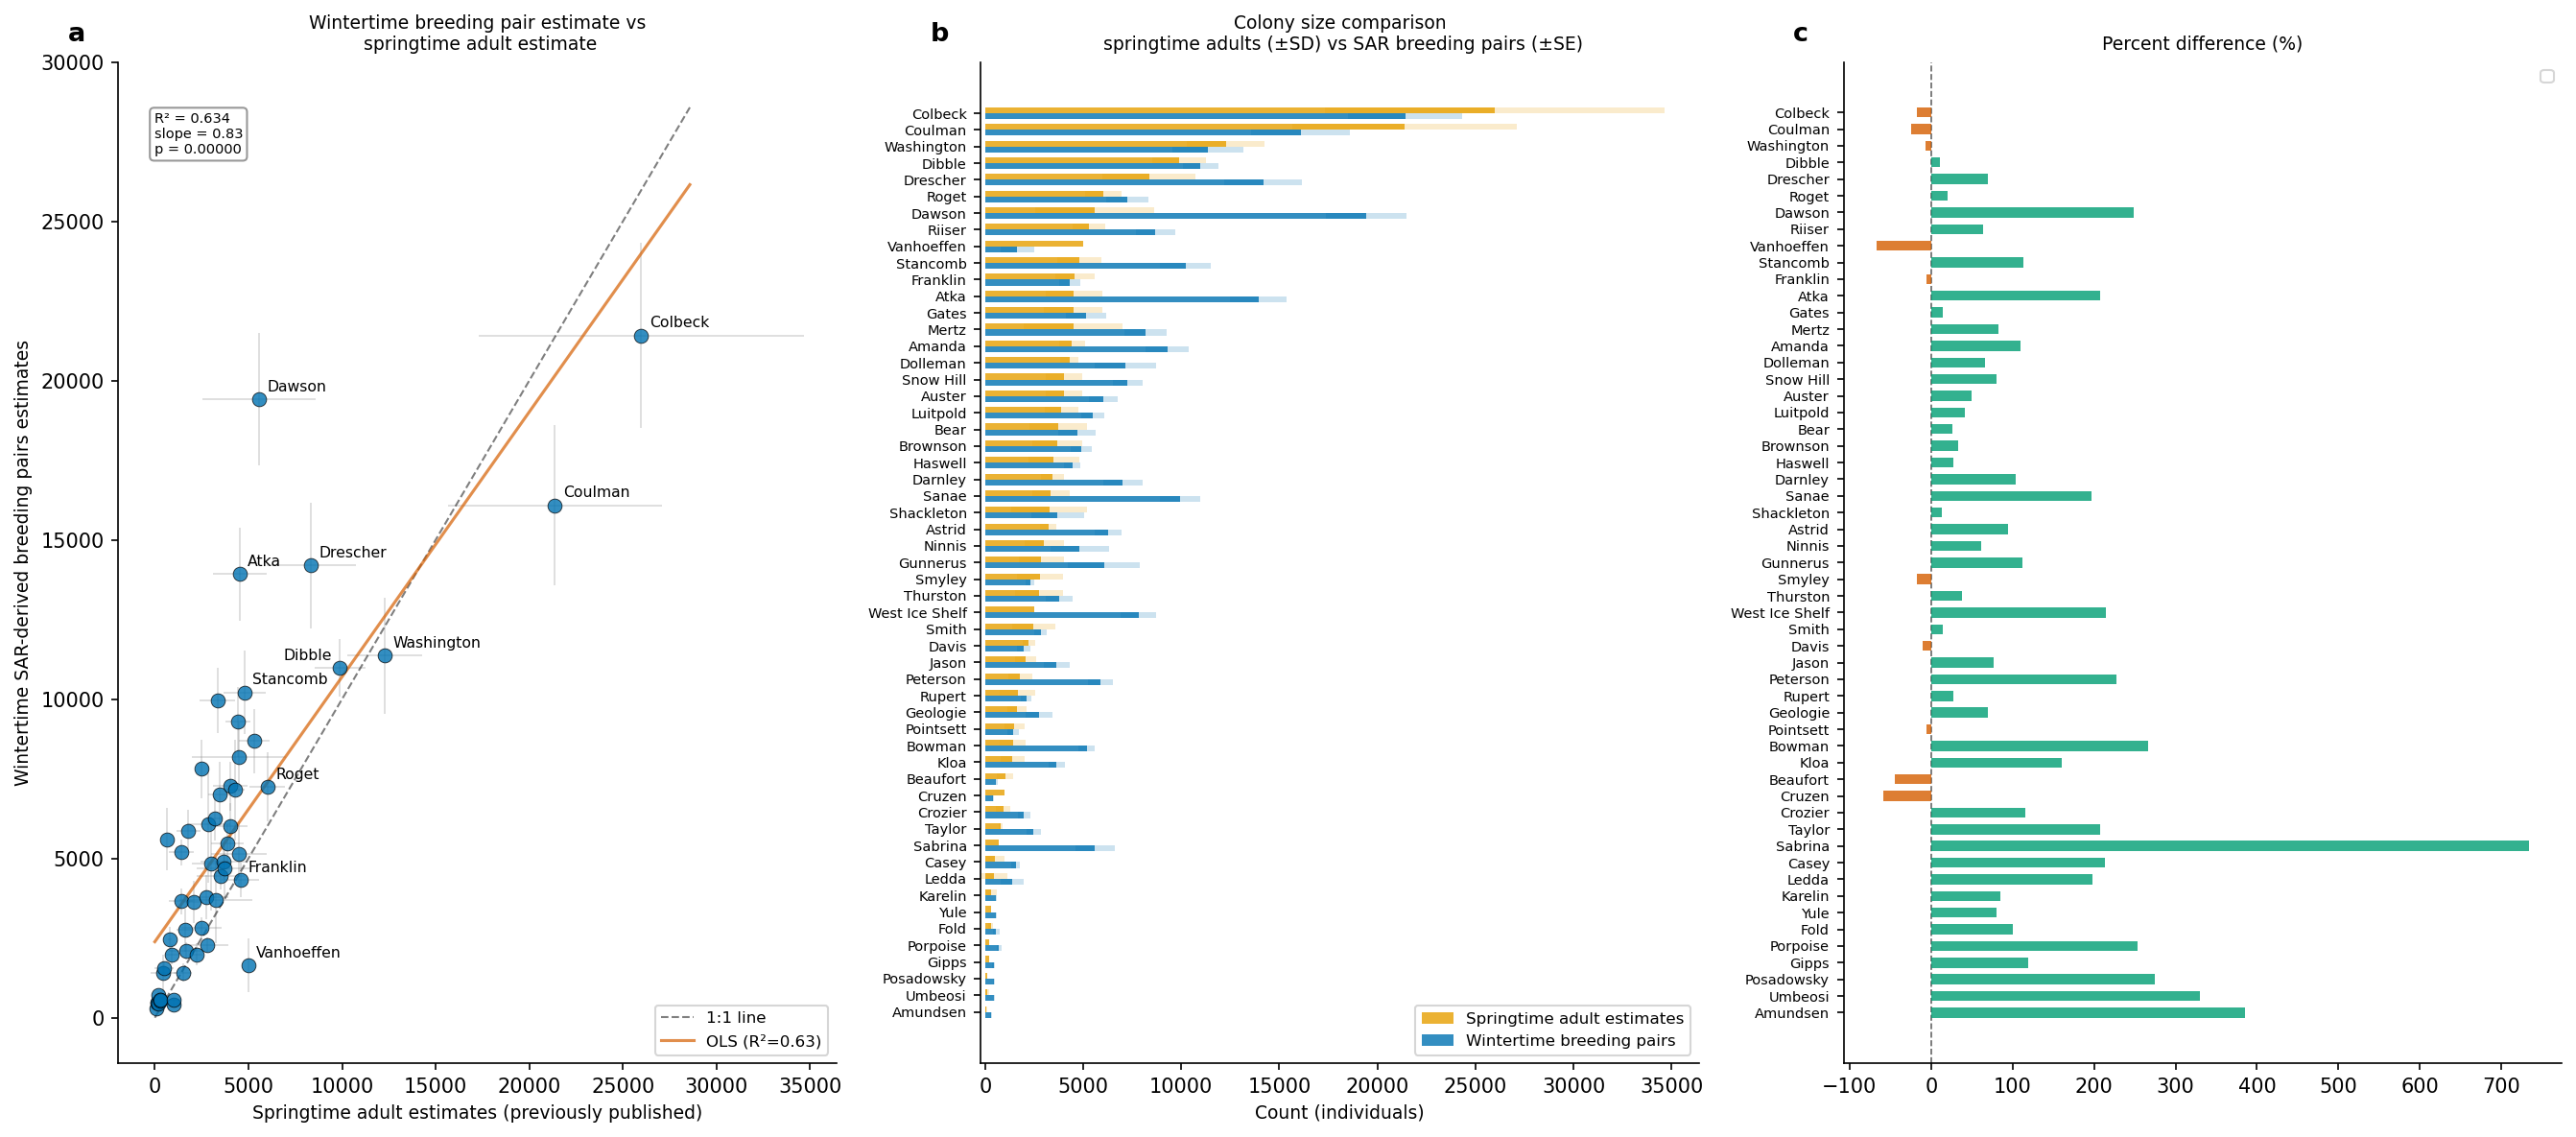


Exported comparison table

Overall statistics:
  R²:              0.634
  Slope:           0.832
  Mean % diff:     105.0%
  Median % diff:   77.0%
  MAPE:            114.5%


<Figure size 960x720 with 0 Axes>

In [ ]:
# ── Merge SAR estimates with est_size data ─────────────────────────────────
dfSizeComp = dfHuddle[[
    "colony_name", "lat", "lon",
    "count_mean", "count_median",
    "combined_se_pm", "combined_lower", "combined_upper",
    "coeff_se_pm", "obs_sem",
    "n_obs", "uncertainty_flag"
]].merge(
    df_est_size[["site_name", "avg_size", "avg_size-sd",
                  "source", "years", "n_years", "method"]],
    left_on="colony_name",
    right_on="site_name",
    how="left"
).drop(columns="site_name")

# Rename for clarity
dfSizeComp = dfSizeComp.rename(columns={"avg_size-sd": "avg_size_sd"})

# Difference metrics
dfSizeComp["diff"]     = dfSizeComp["count_mean"] - dfSizeComp["avg_size"]
dfSizeComp["pct_diff"] = (dfSizeComp["diff"] / dfSizeComp["avg_size"] * 100).round(1)

# Sort by avg_size
dfSizeComp = dfSizeComp.sort_values("avg_size").reset_index(drop=True)

print(f"Matched colonies: {len(dfSizeComp)}")
print(f"\nSummary:")
print(f"  Mean % difference:   {dfSizeComp['pct_diff'].mean():.1f}%")
print(f"  Median % difference: {dfSizeComp['pct_diff'].median():.1f}%")
print(f"  SAR > est_size:      {(dfSizeComp['pct_diff'] > 0).sum()} colonies")
print(f"  SAR < est_size:      {(dfSizeComp['pct_diff'] < 0).sum()} colonies")
print(f"\nColony detail:")
print(dfSizeComp[[
    "colony_name", "avg_size", "avg_size_sd",
    "count_mean", "combined_se_pm",
    "pct_diff", "source", "years"
]].round(0).to_string(index=False))

# ── Three panel plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

colony_order = dfSizeComp["colony_name"].tolist()
y_positions  = {c: i for i, c in enumerate(colony_order)}

# ── Left panel — scatter with 1:1 line ────────────────────────────────────
ax = axes[0]
ax.text(-0.07, 1.04, "a", transform=ax.transAxes,
        fontsize=13, fontweight="bold", va="top", ha="left")

# Error bars — avg_size SD on x, combined SE on y
ax.errorbar(
    dfSizeComp["avg_size"],
    dfSizeComp["count_mean"],
    xerr=dfSizeComp["avg_size_sd"],
    yerr=dfSizeComp["combined_se_pm"],
    fmt="none",
    color="grey", alpha=0.3,
    linewidth=0.8, zorder=2
)
ax.scatter(
    dfSizeComp["avg_size"],
    dfSizeComp["count_mean"],
    s=50, color="#0072B2", alpha=0.8,
    edgecolors="black", linewidths=0.4,
    zorder=3
)

# 1:1 line
lim_max = max(dfSizeComp["avg_size"].max(),
              dfSizeComp["count_mean"].max()) * 1.1
ax.plot([0, lim_max], [0, lim_max],
        "k--", linewidth=1, alpha=0.5, label="1:1 line")

# Regression
from scipy import stats
slope, intercept, r_value, p_value, se = stats.linregress(
    dfSizeComp["avg_size"], dfSizeComp["count_mean"]
)
x_range = np.linspace(0, lim_max, 100)
ax.plot(x_range, slope * x_range + intercept,
        color="#D55E00", linewidth=1.5, linestyle="-",
        alpha=0.7, label=f"OLS (R²={r_value**2:.2f})")

# Label larger colonies
label_colonies = {
    "Colbeck", "Coulman", "Dawson", "Washington",
    "Dibble", "Drescher", "Atka", "Vanhoeffen", "Stancomb", "Franklin", "Roget"
}
label_colonies = {
    "Colbeck":    (4, 4),     
    "Coulman":    (4, 4),     
    "Dawson":     (4, 4),   
    "Washington": (4, 4),     
    "Drescher":   (4, 4),     
    "Dibble":     (-4, 4),   
    "Atka":       (4, 4),   
    "Vanhoeffen":       (4, 4),   
    "Stancomb":       (4, 4),   
    "Franklin":       (4, 4),  
    "Roget":       (4, 4),  
}

for _, r in dfSizeComp.iterrows():
    if r["colony_name"] in label_colonies:
        offset = label_colonies[r["colony_name"]]
        ax.annotate(
            r["colony_name"],
            xy=(r["avg_size"], r["count_mean"]),
            xytext=offset,
            textcoords="offset points",
            fontsize=7.5,
            ha="right" if offset[0] < 0 else "left"
        )

ax.set_xlabel("Springtime adult estimates (previously published)", fontsize=9)
ax.set_ylabel("Wintertime SAR-derived breeding pairs estimates", fontsize=9)
ax.set_title("Wintertime breeding pair estimate vs\n springtime adult estimate", fontsize=9)
ax.legend(fontsize=8)
ax.text(0.05, 0.95,
        f"R² = {r_value**2:.3f}\nslope = {slope:.2f}\np = {p_value:.5f}",
        transform=ax.transAxes, fontsize=7,
        va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="white", alpha=0.8, edgecolor="grey"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ── Middle panel — side by side bars ──────────────────────────────────────
ax = axes[1]
ax.text(-0.07, 1.04, "b", transform=ax.transAxes,
        fontsize=13, fontweight="bold", va="top", ha="left")
bar_height = 0.35

for colony, y in y_positions.items():
    r = dfSizeComp[dfSizeComp["colony_name"] == colony].iloc[0]

    # avg_size bar with SD
    ax.barh(y + bar_height/2, r["avg_size"],
        height=bar_height, color="#E69F00",
        alpha=0.8, label="Springtime adult estimates" if y == 0 else "")

    ax.barh(y + bar_height/2,
            r["avg_size_sd"] * 2,
            left=r["avg_size"] - r["avg_size_sd"],
            height=bar_height, color="#E69F00",
            alpha=0.2, zorder=2)

    # count_mean bar with combined SE
    ax.barh(y - bar_height/2, r["count_mean"],
        height=bar_height, color="#0072B2",
        alpha=0.8, label="Wintertime breeding pairs" if y == 0 else "")
    ax.barh(y - bar_height/2,
            r["combined_upper"] - r["combined_lower"],
            left=r["combined_lower"],
            height=bar_height, color="#0072B2",
            alpha=0.2, zorder=2)

ax.set_yticks(range(len(colony_order)))
ax.set_yticklabels(colony_order, fontsize=7)
ax.set_xlabel("Count (individuals)", fontsize=9)
ax.set_title("Colony size comparison\n springtime adults (±SD) vs SAR breeding pairs (±SE)", fontsize=9)
ax.legend(fontsize=8, loc="lower right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ── Right panel — % difference ────────────────────────────────────────────
ax = axes[2]
ax.text(-0.07, 1.04, "c", transform=ax.transAxes,
        fontsize=13, fontweight="bold", va="top", ha="left")
colors = ["#009E73" if v >= 0 else "#D55E00"
          for v in dfSizeComp["pct_diff"]]

ax.barh(range(len(dfSizeComp)), dfSizeComp["pct_diff"],
        color=colors, alpha=0.8, height=0.6, zorder=3)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)

ax.set_yticks(range(len(colony_order)))
ax.set_yticklabels(colony_order, fontsize=7)
ax.set_title("Percent difference (%)", fontsize=9) #\nSAR wintertime breeding estimate vs springtime estimate
ax.legend(fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.tight_layout()
plt.savefig(os.path.join(INPUTPATH,
            "Final results/fig_size_comparison_estsize_vs_SAR.png"),
            bbox_inches="tight", dpi=600)
plt.show()


# ── Export comparison table ────────────────────────────────────────────────
dfSizeComp.to_csv(
    os.path.join(INPUTPATH,
    "Final results/size_comparison_estsize_vs_SAR.csv"),
    index=False, float_format="%.2f"
)
print(f"\nExported comparison table")
print(f"\nOverall statistics:")
print(f"  R²:              {r_value**2:.3f}")
print(f"  Slope:           {slope:.3f}")
print(f"  Mean % diff:     {dfSizeComp['pct_diff'].mean():.1f}%")
print(f"  Median % diff:   {dfSizeComp['pct_diff'].median():.1f}%")
print(f"  MAPE:            {np.abs(dfSizeComp['pct_diff']).mean():.1f}%")

In [14]:
# ── Top and bottom 5 colonies by % difference ─────────────────────────────
dfSizeComp_sorted = dfSizeComp.sort_values("pct_diff")

print(f"\n{'='*65}")
print("COLONIES WITH LARGEST UNDERESTIMATES (SAR < springtime)")
print("(bottom 5 — most negative % difference)")
print(f"{'='*65}")
print(f"{'Colony':<20} {'avg_size':>10} {'±SD':>8} {'count_mean':>12} "
      f"{'±SE':>8} {'pct_diff':>10}")
print("-" * 70)
for _, r in dfSizeComp_sorted.head(5).iterrows():
    print(f"{r['colony_name']:<20} {r['avg_size']:>10,.0f} "
          f"{r['avg_size_sd']:>8,.0f} "
          f"{r['count_mean']:>12,.0f} "
          f"{r['combined_se_pm']:>8,.0f} "
          f"{r['pct_diff']:>9.1f}%")

print(f"\n{'='*65}")
print("COLONIES WITH LARGEST OVERESTIMATES (SAR > springtime)")
print("(top 5 — most positive % difference)")
print(f"{'='*65}")
print(f"{'Colony':<20} {'avg_size':>10} {'±SD':>8} {'count_mean':>12} "
      f"{'±SE':>8} {'pct_diff':>10}")
print("-" * 70)
for _, r in dfSizeComp_sorted.tail(5).iterrows():
    print(f"{r['colony_name']:<20} {r['avg_size']:>10,.0f} "
          f"{r['avg_size_sd']:>8,.0f} "
          f"{r['count_mean']:>12,.0f} "
          f"{r['combined_se_pm']:>8,.0f} "
          f"{r['pct_diff']:>9.1f}%")

print(f"\n{'='*65}")
print("COLONIES CLOSEST TO 1:1 (best agreement)")
print("(5 closest to 0% difference)")
print(f"{'='*65}")
dfSizeComp_closest = dfSizeComp.reindex(
    dfSizeComp["pct_diff"].abs().sort_values().index
)
print(f"{'Colony':<20} {'avg_size':>10} {'±SD':>8} {'count_mean':>12} "
      f"{'±SE':>8} {'pct_diff':>10}")
print("-" * 70)
for _, r in dfSizeComp_closest.head(5).iterrows():
    print(f"{r['colony_name']:<20} {r['avg_size']:>10,.0f} "
          f"{r['avg_size_sd']:>8,.0f} "
          f"{r['count_mean']:>12,.0f} "
          f"{r['combined_se_pm']:>8,.0f} "
          f"{r['pct_diff']:>9.1f}%")

print(f"\n{'='*65}")
print("SUMMARY")
print(f"{'='*65}")
print(f"  Largest underestimate: "
      f"{dfSizeComp_sorted.iloc[0]['colony_name']} "
      f"({dfSizeComp_sorted.iloc[0]['pct_diff']:.1f}%)")
print(f"  Largest overestimate:  "
      f"{dfSizeComp_sorted.iloc[-1]['colony_name']} "
      f"({dfSizeComp_sorted.iloc[-1]['pct_diff']:.1f}%)")
print(f"  Best agreement:        "
      f"{dfSizeComp_closest.iloc[0]['colony_name']} "
      f"({dfSizeComp_closest.iloc[0]['pct_diff']:.1f}%)")
print(f"  Colonies within ±20%:  "
      f"{(dfSizeComp['pct_diff'].abs() <= 20).sum()} / {len(dfSizeComp)}")
print(f"  Colonies within ±50%:  "
      f"{(dfSizeComp['pct_diff'].abs() <= 50).sum()} / {len(dfSizeComp)}")


COLONIES WITH LARGEST UNDERESTIMATES (SAR < springtime)
(bottom 5 — most negative % difference)
Colony                 avg_size      ±SD   count_mean      ±SE   pct_diff
----------------------------------------------------------------------
Vanhoeffen                5,000      nan        1,636      849     -67.3%
Cruzen                    1,000      nan          412       46     -58.8%
Beaufort                  1,019      403          564       67     -44.7%
Coulman                  21,375    5,727       16,088    2,521     -24.7%
Smyley                    2,792    1,160        2,289      237     -18.0%

COLONIES WITH LARGEST OVERESTIMATES (SAR > springtime)
(top 5 — most positive % difference)
Colony                 avg_size      ±SD   count_mean      ±SE   pct_diff
----------------------------------------------------------------------
Bowman                    1,416      652        5,188      413     266.4%
Posadowsky                  123      nan          460       54     274.3%
Um

In [15]:
# 10 colonies where SAR breeding pair estimate is smallest relative to avg_size
smallest_diff = dfSizeComp.nsmallest(10, "pct_diff")[
    ["colony_name", "avg_size", "avg_size_sd", 
     "count_mean", "combined_se_pm", "pct_diff",
     "source", "years"]
].round(0)

print("10 colonies with largest underestimates (SAR < springtime avg_size):")
print(smallest_diff.to_string(index=False))

10 colonies with largest underestimates (SAR < springtime avg_size):
colony_name  avg_size  avg_size_sd  count_mean  combined_se_pm  pct_diff                  source     years
 Vanhoeffen      5000          NaN      1636.0           849.0     -67.0           Fretwell 2024 2018-2022
     Cruzen      1000          NaN       412.0            46.0     -59.0 Fretwell & Trathan 2020      2019
   Beaufort      1019        403.0       564.0            67.0     -45.0 Foster-Dyer et al. 2026 2000–2024
    Coulman     21375       5727.0     16088.0          2521.0     -25.0 Foster-Dyer et al. 2026 2005–2024
     Smyley      2792       1160.0      2289.0           237.0     -18.0    Fretwell et al. 2025 2009–2023
    Colbeck     25979       8669.0     21418.0          2911.0     -18.0 Foster-Dyer et al. 2026 2005–2024
      Davis      2220        309.0      1983.0           349.0     -11.0       LaRue et al. 2024 2009–2018
 Washington     12271       1990.0     11368.0          1819.0      -7.0   

In [ ]:
# ── Unsampled colonies — in est_size but not in SAR ───────────────────────
df_unsampled = df_est_size[df_est_size["site_name"].isin(unmatched_est)].copy()

print(f"\n{'='*60}")
print("UNSAMPLED COLONIES — in est_size but no SAR coverage")
print(f"{'='*60}")
print(df_unsampled[[
    "site_name", "avg_size", "avg_size-sd",
    "source", "years", "n_years"
]].sort_values("avg_size", ascending=False).to_string(index=False))

# Totals
total_unsampled_mean = df_unsampled["avg_size"].sum()
total_unsampled_sd   = np.sqrt((df_unsampled["avg_size-sd"] ** 2).sum())

print(f"\nUnsampled colony totals:")
print(f"  n colonies:          {len(df_unsampled)}")
print(f"  Total avg_size:      {total_unsampled_mean:,.0f} individuals")
print(f"  Combined SD ±:       {total_unsampled_sd:,.0f} individuals")

# Compare to SAR total
sar_total            = dfSizeComp["count_mean"].sum()
sar_combined_se      = np.sqrt((dfSizeComp["combined_se_pm"] ** 2).sum())

print(f"\nSAR sampled total:")
print(f"  n colonies:          {len(dfSizeComp)}")
print(f"  Total count_mean:    {sar_total:,.0f} individuals")
print(f"  Combined SE ±:       {sar_combined_se:,.0f} individuals")

# Grand total
grand_total    = sar_total + total_unsampled_mean
grand_total_se = np.sqrt(sar_combined_se ** 2 + total_unsampled_sd ** 2)

print(f"\nGrand total (SAR + unsampled literature estimates):")
print(f"  Total:               {grand_total:,.0f} individuals")
print(f"  Combined SE ±:       {grand_total_se:,.0f} individuals")
print(f"  Unsampled as % of SAR total: "
      f"{total_unsampled_mean / sar_total * 100:.1f}%")
print(f"\nNote: unsampled estimates from mixed methods and years")
print(f"({df_unsampled['years'].unique()}) — treat grand total with caution")



UNSAMPLED COLONIES — in est_size but no SAR coverage
 site_name  avg_size  avg_size-sd                   source     years  n_years
  Ragnhild      4784       1481.0        LaRue et al. 2024 2009–2018       10
     Gould      3481        926.0     Fretwell et al. 2025 2009–2023       15
   Noville      2986        777.0        LaRue et al. 2024 2009–2018       10
     Verdi      1500        500.0  Fretwell & Trathan 2020      2019        1
  Pfrogner      1500        500.0  Fretwell & Trathan 2020      2019        1
   Lataday      1400        500.0 Fretwell et al. preprint      2024        1
     Bryan      1350        666.0     Fretwell et al. 2025 2009–2023       15
   Phoenix      1350        500.0 Fretwell et al. preprint      2025        1
    Halley       841        799.0     Fretwell et al. 2025      2023        1
Rothschild       828        267.0     Fretwell et al. 2025 2009–2023       15
      Case       750        250.0 Fretwell et al. preprint      2023        1
  Verleger